# HMM Pipeline V2 — Data-driven model selection

Phiên bản viết lại **không bám proposal**. Để dữ liệu tự chọn:

1. **Số feature** (6–10) qua greedy MI + VIF gate + block coverage
2. **Số state K** (2–5) qua grid search trên BIC + persistence + balance
3. **Nhãn** auto-gán theo quadrant (return × vol) — generalize cho mọi K

**Output**: `output/v2/` — không overwrite phiên bản cũ ở `output/`.

**Tiêu chí "tốt nhất"**:
- BIC thấp (penalize complexity)
- Log-likelihood OOS (2020–2024) cao (generalize tốt)
- Min expected duration ≥ 5 ngày (regime không flicker)
- Min state share ≥ 5% và max ≤ 70% (balanced)

Composite rank = `0.4·rank(BIC) + 0.4·rank(LL_OOS) + 0.2·rank(min_dur)`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, pickle
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import skew, kurtosis
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH  = Path('macro_features.xlsx - Data.xlsx')
OUTPUT_DIR = Path('output/test')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HMM_TRAIN_END = pd.Timestamp('2019-12-31')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('Setup OK')

Setup OK


## 1. Load + transformations

Thêm 2 transformation so với V1:
- `vnindex_ret_5d` (short-term trend)
- `volume_z20` (z-score volume — tách hoạt động cao bất thường khỏi level)


In [2]:
df = pd.read_excel(DATA_PATH, sheet_name='Sheet1')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Transformations
df['vix_diff']         = df['vix_log'].diff()
df['vnindex_ret_5d']   = df['vnindex_log_ret'].rolling(5).sum()
df['vnindex_ret_20d']  = df['vnindex_log_ret'].rolling(20).sum()
df['volume_z20']       = (df['volume_ratio_hose'] - df['volume_ratio_hose'].rolling(20).mean()) \
                         / df['volume_ratio_hose'].rolling(20).std()
qlo, qhi = df['interbank_on_diff'].quantile([0.01, 0.99])
df['interbank_on_diff'] = df['interbank_on_diff'].clip(qlo, qhi)

print(f'Shape: {df.shape},  dates: {df["date"].min().date()} -> {df["date"].max().date()}')

FileNotFoundError: [Errno 2] No such file or directory: 'macro_features.xlsx - Data.xlsx'

## 2. Pool 18 candidates qua 4 khối E/M/S/C


In [3]:
BLOCKS = {
    'M': ['vnindex_log_ret', 'vnindex_ret_5d', 'vnindex_ret_20d',
          'vnindex_vol20', 'volume_ratio_hose', 'volume_z20',
          'vix_diff', 'sp500_ret'],
    'E': ['fx_log_ret', 'interbank_on_diff', 'vn5y_yield_diff', 'epu_log', 'gpr_log'],
    'S': ['oil_ret', 'gold_ret'],
    'C': ['fnb_ratio', 'amihud_diff', 'ret_disp'],
}
candidates = ["m1_ret5d",
"e8_cpi_mom",
"g1_dxy_ret",
"s3_pmi_vn",
"e3_vn5y_yield_diff",
"c1_amihud_transformed",
"m4_fnb_ratio",
"m1_ret20d"
"m1_mkt_ret"
"m5_hose_vol_z"]
print(f'{len(candidates)} candidates qua 4 khoi')
for b, vs in BLOCKS.items():
    print(f'  {b}: {vs}')

8 candidates qua 4 khoi
  M: ['vnindex_log_ret', 'vnindex_ret_5d', 'vnindex_ret_20d', 'vnindex_vol20', 'volume_ratio_hose', 'volume_z20', 'vix_diff', 'sp500_ret']
  E: ['fx_log_ret', 'interbank_on_diff', 'vn5y_yield_diff', 'epu_log', 'gpr_log']
  S: ['oil_ret', 'gold_ret']
  C: ['fnb_ratio', 'amihud_diff', 'ret_disp']


## 3. Filter — stationarity (ADF + KPSS) & Gaussianity (|kurt| < 8)

Loại biến không đạt 2 tiêu chí cơ bản trước khi cho vào pool:
- Phải I(0): ADF p<0.05 **và** KPSS p≥0.05
- |Excess kurtosis| < 8 (Gaussian HMM emission)


In [4]:
def stat_test(s):
    s = s.dropna()
    p_adf  = adfuller(s, autolag='AIC')[1]
    p_kpss = kpss(s, regression='c', nlags='auto')[1]
    return (p_adf < 0.05) and (p_kpss >= 0.05)

rows = []
for c in candidates:
    s  = df[c].dropna()
    is_stat = stat_test(df[c])
    k  = kurtosis(s)
    sk = skew(s)
    rows.append({
        'feature': c,
        'block':  next(b for b,vs in BLOCKS.items() if c in vs),
        'stationary': is_stat,
        'kurt': k,
        'skew': sk,
        'pass_kurt': abs(k) < 10,   # loose threshold (V1 dung 10) de giu vix_diff
    })
filt = pd.DataFrame(rows)
filt['keep'] = filt['stationary'] & filt['pass_kurt']
print(filt.round(3).to_string(index=False))

keep_pool = filt.loc[filt['keep'], 'feature'].tolist()
print(f'\nPool sau filter: {len(keep_pool)} / {len(candidates)} features')
dropped = filt.loc[~filt['keep']]
if len(dropped):
    print('Loai:')
    for _, r in dropped.iterrows():
        why = []
        if not r['stationary']: why.append('non-stationary')
        if not r['pass_kurt']:  why.append(f"kurt={r['kurt']:.1f}")
        print(f"  - {r['feature']}: {', '.join(why)}")

NameError: name 'df' is not defined

## 4. MI ranking với |VN-Index daily return|

MI cao = feature giúp phân biệt regime vol cao / vol thấp tốt.


In [5]:
# Target: |VN-Index daily log return| (regime signal)
sub_X = df[keep_pool].copy()
sub_y = df['vnindex_log_ret'].abs()
mask  = sub_X.notna().all(axis=1) & sub_y.notna()
mi_scores = mutual_info_regression(
    sub_X.loc[mask].values,
    sub_y.loc[mask].values.ravel(),
    random_state=RANDOM_STATE
)
mi_df = pd.DataFrame({'feature': keep_pool, 'mi': mi_scores})
mi_df['block'] = [next(b for b,vs in BLOCKS.items() if c in vs) for c in mi_df['feature']]
mi_df = mi_df.sort_values('mi', ascending=False).reset_index(drop=True)
print(mi_df.to_string(index=False))

          feature     mi block
  vnindex_log_ret 5.6344     M
   vnindex_ret_5d 0.1114     M
    vnindex_vol20 0.1039     M
  vnindex_ret_20d 0.0592     M
       volume_z20 0.0263     M
         vix_diff 0.0183     M
        fnb_ratio 0.0086     C
       fx_log_ret 0.0065     E
         gold_ret 0.0037     S
volume_ratio_hose 0.0003     M
interbank_on_diff 0.0000     E
  vn5y_yield_diff 0.0000     E


## 5. Greedy feature selection — block coverage + VIF gate

Quy tắc:
1. **Pass 1**: Lấy top-MI từng block (đảm bảo M, E, C có đại diện; S optional)
2. **Pass 2**: Greedy thêm theo MI ranking, bỏ qua feature làm max(VIF) ≥ 5

Sinh ra 5 bộ feature (n=6,7,8,9,10) để grid search.


In [6]:
def greedy_select(pool, mi_rank, n_target, df, blocks, max_vif=5.0, required_blocks=('M','E','C')):
    selected = []
    seen_blocks = set()

    # Pass 1: top-MI per required block
    for b in required_blocks:
        in_block = [f for f in mi_rank if f in blocks.get(b, [])]
        if in_block:
            selected.append(in_block[0])
            seen_blocks.add(b)

    # Pass 2: greedy by MI, gate by VIF
    remaining = [f for f in mi_rank if f not in selected]
    for f in remaining:
        if len(selected) >= n_target:
            break
        trial = selected + [f]
        Xt = df[trial].dropna().values
        if Xt.shape[0] < 100:
            continue
        try:
            vifs = [variance_inflation_factor(Xt, i) for i in range(len(trial))]
            if max(vifs) < max_vif:
                selected.append(f)
        except Exception:
            continue
    return selected

mi_ranked = mi_df['feature'].tolist()
feature_sets = {n: greedy_select(keep_pool, mi_ranked, n, df, BLOCKS) for n in [6, 7, 8, 9, 10]}
for n, fs in feature_sets.items():
    print(f'n={n}: {fs}')

n=6: ['vnindex_log_ret', 'fx_log_ret', 'fnb_ratio', 'vnindex_ret_5d', 'vnindex_vol20', 'vnindex_ret_20d']
n=7: ['vnindex_log_ret', 'fx_log_ret', 'fnb_ratio', 'vnindex_ret_5d', 'vnindex_vol20', 'vnindex_ret_20d', 'volume_z20']
n=8: ['vnindex_log_ret', 'fx_log_ret', 'fnb_ratio', 'vnindex_ret_5d', 'vnindex_vol20', 'vnindex_ret_20d', 'volume_z20', 'vix_diff']
n=9: ['vnindex_log_ret', 'fx_log_ret', 'fnb_ratio', 'vnindex_ret_5d', 'vnindex_vol20', 'vnindex_ret_20d', 'volume_z20', 'vix_diff', 'gold_ret']
n=10: ['vnindex_log_ret', 'fx_log_ret', 'fnb_ratio', 'vnindex_ret_5d', 'vnindex_vol20', 'vnindex_ret_20d', 'volume_z20', 'vix_diff', 'gold_ret', 'interbank_on_diff']


## 6. Train/HMM split + scaler helper

Scaler luôn fit trên 2015–2019 only — chống look-ahead bias.


In [7]:
def make_Z(features):
    fd    = df[['date'] + features].dropna().reset_index(drop=True)
    train = fd[fd['date'] <= HMM_TRAIN_END][features].values
    sc    = StandardScaler().fit(train)
    Z_tr  = sc.transform(train)
    Z_all = sc.transform(fd[features].values)
    return fd, Z_tr, Z_all, sc

print('Helper ready')

Helper ready


## 7. Grid search (K, n_features) — fit + diagnostic


In [8]:
def fit_hmm(Z, K, n_seeds=5, max_iter=500):
    best_ll, best = -np.inf, None
    for seed in range(n_seeds):
        try:
            m = GaussianHMM(n_components=K, covariance_type='full',
                            n_iter=max_iter, tol=1e-4, random_state=seed*7+1)
            m.fit(Z)
            ll = m.score(Z)
            if ll > best_ll:
                best_ll, best = ll, m
        except Exception:
            continue
    return best, best_ll

def n_params(K, D):
    return K*(D + D*(D+1)/2) + K*(K-1) + (K-1)

def evaluate(model, Z_train, Z_oos):
    K        = model.n_components
    persist  = np.diag(model.transmat_)
    duration = 1.0 / (1.0 - persist + 1e-9)
    states   = model.predict(Z_train)
    counts   = np.bincount(states, minlength=K) / len(states)
    return {
        'll_oos':    model.score(Z_oos) if len(Z_oos) > 0 else np.nan,
        'min_dur':   float(duration.min()),
        'min_share': float(counts.min()),
        'max_share': float(counts.max()),
    }

In [9]:
results = []
for n_feat, fs in feature_sets.items():
    fd, Z_tr, Z_all, sc = make_Z(fs)
    Z_oos = Z_all[len(Z_tr):]
    D, n  = Z_tr.shape[1], Z_tr.shape[0]
    for K in [2, 3, 4, 5]:
        m, ll = fit_hmm(Z_tr, K, n_seeds=5)
        if m is None:
            continue
        p   = n_params(K, D)
        bic = -2*ll + p*np.log(n)
        ev  = evaluate(m, Z_tr, Z_oos)
        results.append({
            'n_feat':    n_feat,
            'K':         K,
            'D':         D,
            'll_in':     ll,
            'bic':       bic,
            'n_params':  p,
            'll_oos':    ev['ll_oos'],
            'min_dur':   ev['min_dur'],
            'min_share': ev['min_share'],
            'max_share': ev['max_share'],
        })

res = pd.DataFrame(results)
print(res.round(2).to_string(index=False))

Model is not converging.  Current: -9040.292997834567 is not greater than -9040.04380133254. Delta is -0.24919650202718913
Model is not converging.  Current: -9013.013792439337 is not greater than -9013.013746156546. Delta is -4.62827902083518e-05
Model is not converging.  Current: -12790.253760461164 is not greater than -12790.253608088336. Delta is -0.00015237282786983997


 n_feat  K  D       ll_in        bic  n_params      ll_oos  min_dur  min_share  max_share
      6  2  6  -8702.9900 17811.3800   57.0000 -10121.8700  40.7700     0.4000     0.6000
      6  3  6  -7987.3600 16607.7200   89.0000  -9235.6600   7.9000     0.2700     0.4400
      6  4  6  -7477.4000 15829.6200  123.0000  -9114.4500   7.6800     0.1200     0.4200
      6  5  6  -7345.4700 15821.8000  159.0000  -9529.2300   5.2200     0.0500     0.3700
      7  2  7 -10408.8900 21336.9700   73.0000 -11840.5900  38.6000     0.3800     0.6200
      7  3  7  -9676.0700 20155.8400  113.0000 -10974.9300   7.8500     0.2700     0.4400
      7  4  7  -9233.2900 19568.9800  155.0000 -10961.1800   8.3800     0.1800     0.3300
      7  5  7  -8823.5300 19062.4100  199.0000 -10890.3800   7.2300     0.1200     0.3600
      8  2  8 -12120.9600 24889.1500   91.0000 -13559.9800  38.2200     0.3900     0.6100
      8  3  8 -11388.8300 23773.3900  140.0000 -12610.7600   8.8500     0.2700     0.4000
      8  4

## 8. Composite scoring + chọn best config

**Hard filter**:
- `K ≥ 3` (K=2 quá thô — không phân biệt được sideways khỏi crisis)
- `5 ≤ min_dur ≤ 30` (≥5 chống flicker, ≤30 chống "stuck" như K=2)
- `min_share ≥ 0.05`, `max_share ≤ 0.70`

**Composite** (rank-based, smaller = better):
- 0.5 × rank(BIC) — model fit + parsimony
- 0.5 × rank(LL_OOS) — generalization 2020–2024
- Tiebreak: K thấp hơn (parsimony Occam)


In [10]:
valid = res[
    (res['K']         >= 3) &
    (res['min_dur']   >= 5.0) &
    (res['min_dur']   <= 30.0) &
    (res['min_share'] >= 0.05) &
    (res['max_share'] <= 0.70)
].copy()

if len(valid) == 0:
    print('Khong config nao pass — relax filter')
    valid = res[(res['K'] >= 3) & (res['min_dur'] >= 3.0)].copy()

valid['rank_bic']  = valid['bic'].rank(ascending=True)
valid['rank_oos']  = valid['ll_oos'].rank(ascending=False)
valid['composite'] = 0.5*valid['rank_bic'] + 0.5*valid['rank_oos']
# Tiebreak: K nho hon (parsimony)
valid = valid.sort_values(['composite', 'K']).reset_index(drop=True)

print('TOP 10 config (sau hard filter):')
print(valid.head(10).round(2).to_string(index=False))

best          = valid.iloc[0]
N_BEST, K_BEST = int(best['n_feat']), int(best['K'])
HMM_FEATURES   = feature_sets[N_BEST]

print(f'\n>>> Chon n_feat={N_BEST}, K={K_BEST}')
print(f'>>> Features ({N_BEST}):')
for i, f in enumerate(HMM_FEATURES, 1):
    b = next(b for b,vs in BLOCKS.items() if f in vs)
    print(f'  {i}. [{b}] {f}')

TOP 10 config (sau hard filter):
 n_feat  K  D       ll_in        bic  n_params      ll_oos  min_dur  min_share  max_share  rank_bic  rank_oos  composite
      6  4  6  -7477.4000 15829.6200  123.0000  -9114.4500   7.6800     0.1200     0.4200    2.0000    1.0000     1.5000
      6  5  6  -7345.4700 15821.8000  159.0000  -9529.2300   5.2200     0.0500     0.3700    1.0000    3.0000     2.0000
      6  3  6  -7987.3600 16607.7200   89.0000  -9235.6600   7.9000     0.2700     0.4400    3.0000    2.0000     2.5000
      7  5  7  -8823.5300 19062.4100  199.0000 -10890.3800   7.2300     0.1200     0.3600    4.0000    4.0000     4.0000
      7  4  7  -9233.2900 19568.9800  155.0000 -10961.1800   8.3800     0.1800     0.3300    5.0000    5.0000     5.0000
      7  3  7  -9676.0700 20155.8400  113.0000 -10974.9300   7.8500     0.2700     0.4400    6.0000    6.0000     6.0000
      8  4  8 -10864.8500 23088.1500  191.0000 -12545.0700   7.4000     0.1200     0.4100    8.0000    7.0000     7.5000

## 9. Refit best config với 10 seed (final model)


In [11]:
fd, Z_tr, Z_all, scaler = make_Z(HMM_FEATURES)
hmm, ll = fit_hmm(Z_tr, K_BEST, n_seeds=10)
print(f'Final LL = {ll:.1f},  converged = {hmm.monitor_.converged},  iters = {hmm.monitor_.iter}')

regime_hard = hmm.predict(Z_all)
regime_prob = hmm.predict_proba(Z_all)
fd['regime'] = regime_hard

stats_rows = []
for k in range(K_BEST):
    mask = fd['regime'] == k
    stats_rows.append({
        'state':       k,
        'n_days':      int(mask.sum()),
        'pct':         100*mask.mean(),
        'mean_ret_%':  fd.loc[mask, 'vnindex_log_ret'].mean()*100 if 'vnindex_log_ret' in fd.columns else np.nan,
        'vol_%':       fd.loc[mask, 'vnindex_vol20'].mean()*100   if 'vnindex_vol20'   in fd.columns else np.nan,
    })
rs = pd.DataFrame(stats_rows)
print('\nState characteristics:')
print(rs.round(3).to_string(index=False))

Final LL = -7477.4,  converged = True,  iters = 88

State characteristics:
 state  n_days     pct  mean_ret_%   vol_%
     0     674 27.2320      0.0930 14.8070
     1     824 33.2930     -0.0880 24.6970
     2     766 30.9490      0.0860  9.8260
     3     211  8.5250      0.0960  9.9960


## 10. Auto-label (K-agnostic)

| K | Naming scheme |
|---|---|
| 2 | Risk-On / Risk-Off (theo vol) |
| 3 | Bull / Sideways / Bear (theo rule 2D cũ — Guidolin & Timmermann 2007) |
| 4 | Tranquil / Euphoria / Drift / Crisis (quadrant return × vol) |
| 5 | Tier1..Tier5 (theo vol descending) |


In [12]:
def auto_label(rs, K):
    """K-agnostic labeling.

    K=4 dung cutoff RET=0 (khong median) de tranh nham 'Calm Bull' thanh 'Drift'
    khi market co positive long-term drift (VN-Index).
    """
    ret = rs['mean_ret_%'].values
    vol = rs['vol_%'].values
    if K == 2:
        order = np.argsort(vol)
        return {int(order[0]): 'Risk-On', int(order[1]): 'Risk-Off'}
    if K == 3:
        bear = int(np.argmin(ret))
        rest = [s for s in range(K) if s != bear]
        bull = int(min(rest, key=lambda s: vol[s]))
        side = [s for s in rest if s != bull][0]
        return {bull: 'Bull', side: 'Sideways', bear: 'Bear'}
    if K == 4:
        vol_med = np.median(vol)
        labels  = {}
        for k in range(K):
            up   = ret[k] >= 0          # cutoff RET = 0, KHONG median
            calm = vol[k] <  vol_med
            if   up and calm:           labels[k] = 'CalmBull'
            elif up and not calm:       labels[k] = 'Euphoria'
            elif (not up) and calm:     labels[k] = 'Drift'
            else:                        labels[k] = 'Crisis'
        # Neu trung label (vd 2 state cung CalmBull) -> tach bang share/vol
        from collections import Counter
        cnt = Counter(labels.values())
        if any(v > 1 for v in cnt.values()):
            for lbl_dup in [l for l,c in cnt.items() if c > 1]:
                dup_states = [k for k,l in labels.items() if l == lbl_dup]
                # State vol thap nhat trong nhom giu nhan goc, state con lai -> 'Tranquil' (rare calm)
                dup_states_sorted = sorted(dup_states, key=lambda s: vol[s])
                for s in dup_states_sorted[1:]:
                    labels[s] = 'Tranquil'
        return labels
    # K >= 5
    order = np.argsort(-vol)
    return {int(order[i]): f'Tier{i+1}' for i in range(K)}

STATE_TO_LABEL = auto_label(rs, K_BEST)
fd['label']    = fd['regime'].map(STATE_TO_LABEL)

print('Mapping state -> label:')
for s, l in sorted(STATE_TO_LABEL.items()):
    r = rs.loc[s]
    print(f'  state {s} -> {l:<12} ret={r["mean_ret_%"]:+.3f}%/d   vol={r["vol_%"]:6.2f}%   share={r["pct"]:5.1f}%')

# Transition matrix
trans = pd.DataFrame(hmm.transmat_,
    index   = [f'{STATE_TO_LABEL[i]}({i})' for i in range(K_BEST)],
    columns = [f'{STATE_TO_LABEL[i]}({i})' for i in range(K_BEST)])
print('\nTransition matrix:')
print(trans.round(3).to_string())

dur = 1.0 / (1.0 - np.diag(hmm.transmat_) + 1e-9)
print('\nExpected duration:')
for i in range(K_BEST):
    print(f'  {STATE_TO_LABEL[i]:<12} ~ {dur[i]:.1f} ngay')

Mapping state -> label:
  state 0 -> Euphoria     ret=+0.093%/d   vol= 14.81%   share= 27.2%
  state 1 -> Crisis       ret=-0.088%/d   vol= 24.70%   share= 33.3%
  state 2 -> CalmBull     ret=+0.086%/d   vol=  9.83%   share= 30.9%
  state 3 -> Tranquil     ret=+0.096%/d   vol= 10.00%   share=  8.5%

Transition matrix:
             Euphoria(0)  Crisis(1)  CalmBull(2)  Tranquil(3)
Euphoria(0)       0.8700     0.0770       0.0440       0.0090
Crisis(1)         0.0860     0.9140       0.0000       0.0000
CalmBull(2)       0.0090     0.0120       0.9440       0.0350
Tranquil(3)       0.0140     0.0000       0.1150       0.8710

Expected duration:
  Euphoria     ~ 7.7 ngay
  Crisis       ~ 11.6 ngay
  CalmBull     ~ 17.9 ngay
  Tranquil     ~ 7.8 ngay


## 11. Sanity check — sự kiện lịch sử


In [13]:
events = {
    'Trade war 2018':  '2018-04-10',
    'COVID crash':     '2020-03-24',
    'Bull peak 2021':  '2021-11-25',
    'Bond crisis':     '2022-10-25',
    'Carry unwind':    '2024-08-05',
}
print(f'{"Event":<22}{"Date":<14}{"Label":<14}{"Posterior":>10}')
print('-'*62)
for e, d in events.items():
    t = pd.Timestamp(d)
    if (fd['date'] - t).abs().min() > pd.Timedelta('5D'):
        continue
    idx = (fd['date'] - t).abs().idxmin()
    s   = int(fd.loc[idx, 'regime'])
    print(f'{e:<22}{str(fd.loc[idx,"date"].date()):<14}{STATE_TO_LABEL[s]:<14}{regime_prob[idx,s]:>10.3f}')

Event                 Date          Label          Posterior
--------------------------------------------------------------
Trade war 2018        2018-04-10    Crisis             0.858
COVID crash           2020-03-24    Crisis             1.000
Bull peak 2021        2021-11-25    Euphoria           0.999
Bond crisis           2022-10-25    Crisis             1.000
Carry unwind          2024-08-05    Crisis             1.000


## 12. Plot regime timeline trên VN-Index


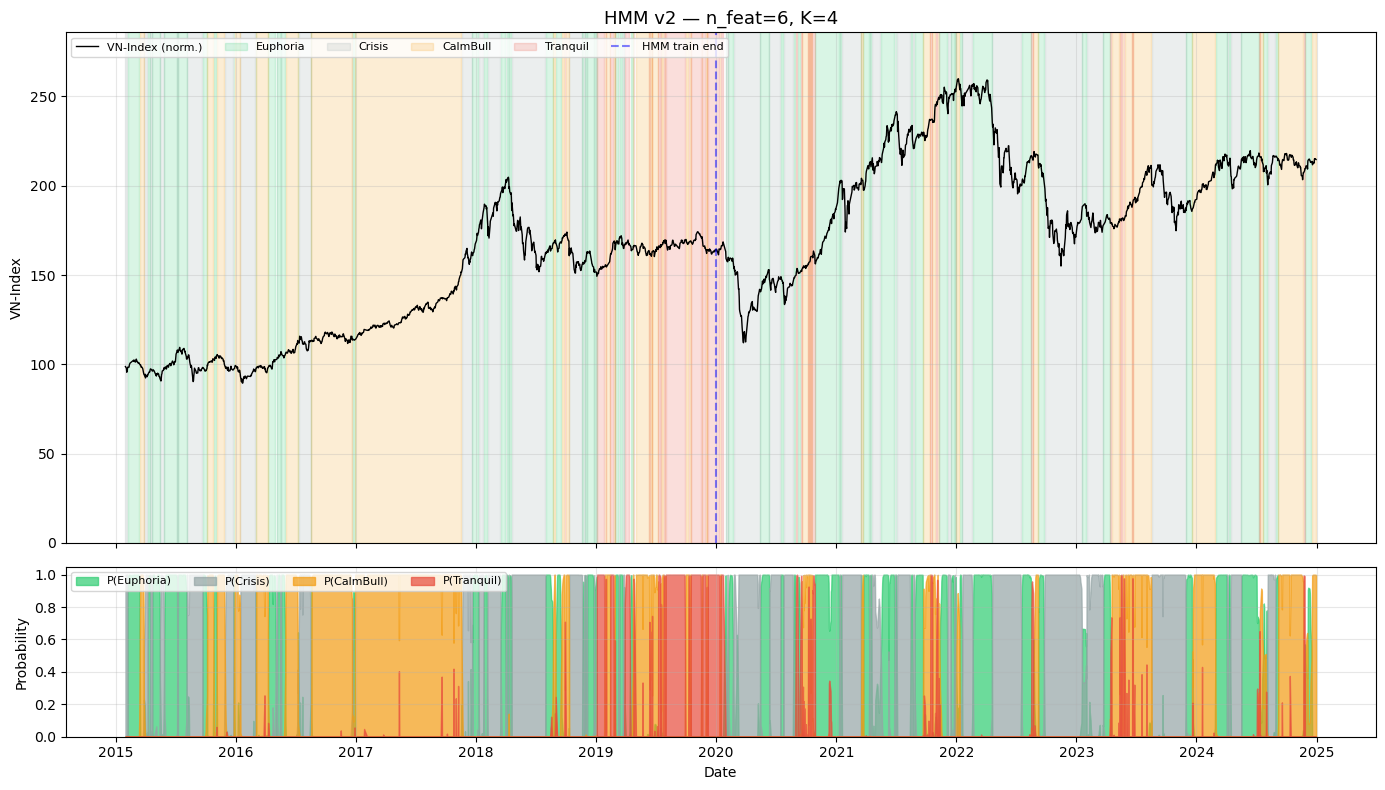

Saved: output\v2\hmm_regime_timeline.png


In [14]:
fd['vn_idx'] = (np.exp(fd['vnindex_log_ret'].cumsum()) * 100
                if 'vnindex_log_ret' in fd.columns else np.nan)

palette = ['#2ecc71', '#95a5a6', '#f39c12', '#e74c3c', '#9b59b6']
state_colors = {s: palette[i % len(palette)] for i, s in enumerate(sorted(STATE_TO_LABEL))}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.plot(fd['date'], fd['vn_idx'], color='black', lw=1, label='VN-Index (norm.)')
ymax = fd['vn_idx'].max() * 1.1
for s in sorted(STATE_TO_LABEL):
    mask = fd['regime'] == s
    ax.fill_between(fd['date'], 0, ymax, where=mask,
                    color=state_colors[s], alpha=0.18, label=STATE_TO_LABEL[s])
ax.axvline(HMM_TRAIN_END, color='blue', ls='--', alpha=0.5, label='HMM train end')
ax.set_ylim(0, ymax)
ax.set_ylabel('VN-Index')
ax.set_title(f'HMM v2 — n_feat={N_BEST}, K={K_BEST}', fontsize=13)
ax.legend(loc='upper left', ncol=K_BEST+2, fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
for s in sorted(STATE_TO_LABEL):
    ax.fill_between(fd['date'], 0, regime_prob[:, s],
                    color=state_colors[s], alpha=0.7, label=f'P({STATE_TO_LABEL[s]})')
ax.set_ylabel('Probability')
ax.set_xlabel('Date')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', ncol=K_BEST, fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hmm_regime_timeline.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "hmm_regime_timeline.png"}')

## 13. Yearly distribution


In [15]:
fd['year'] = fd['date'].dt.year
yearly = (fd.groupby('year')['label']
            .value_counts(normalize=True)
            .mul(100).round(1)
            .unstack(fill_value=0))
print(yearly.to_string())

label  CalmBull  Crisis  Euphoria  Tranquil
year                                       
2015    19.7000 34.9000   45.4000    0.0000
2016    61.0000 23.5000   15.5000    0.0000
2017    88.0000  8.8000    3.2000    0.0000
2018     8.1000 57.3000   33.9000    0.8000
2019    29.6000  1.6000    9.2000   59.6000
2020     7.5000 41.7000   38.1000   12.7000
2021    12.0000 40.8000   43.6000    3.6000
2022     5.6000 59.8000   32.9000    1.6000
2023    34.1000 48.2000   13.3000    4.4000
2024    43.1000 16.5000   38.7000    1.6000


## 14. Save outputs


In [16]:
out = pd.DataFrame({
    'date':         fd['date'].values,
    'regime_hard':  regime_hard,
    'regime_label': fd['label'].values,
})
for s in sorted(STATE_TO_LABEL):
    col = 'prob_' + STATE_TO_LABEL[s].lower().replace('-', '_')
    out[col] = regime_prob[:, s]

out.to_csv(OUTPUT_DIR / 'hmm_regimes.csv', index=False)

with open(OUTPUT_DIR / 'hmm_model.pkl', 'wb') as f:
    pickle.dump({
        'hmm':            hmm,
        'scaler':         scaler,
        'features':       HMM_FEATURES,
        'state_to_label': STATE_TO_LABEL,
        'K':              K_BEST,
        'n_features':     N_BEST,
        'feature_sets':   feature_sets,
        'grid_results':   res,
        'top10':          valid.head(10),
    }, f)

# Merge into master for DRL
prob_cols = [c for c in out.columns if c.startswith('prob_')]
master = df.merge(out[['date'] + prob_cols], on='date', how='left')
for c in prob_cols:
    master[c] = master[c].fillna(1.0/K_BEST)
master.to_parquet(OUTPUT_DIR / 'master_drl_ready.parquet', index=False)

print(f'Saved -> {OUTPUT_DIR}/')
print(f'  hmm_regimes.csv          ({len(out)} rows)')
print(f'  hmm_model.pkl            (K={K_BEST}, n_feat={N_BEST})')
print(f'  master_drl_ready.parquet ({len(master)} x {len(master.columns)})')
print(f'  hmm_regime_timeline.png')

Saved -> output\v2/
  hmm_regimes.csv          (2475 rows)
  hmm_model.pkl            (K=4, n_feat=6)
  master_drl_ready.parquet (2495 x 76)
  hmm_regime_timeline.png


## 15. Methodology snippet (for paper)

> We perform a two-dimensional grid search over feature count $n \in \{6,7,8,9,10\}$ and
> hidden state count $K \in \{2,3,4,5\}$ to identify the optimal Gaussian HMM specification
> for the Vietnamese equity market regime. Features are pre-screened by ADF/KPSS stationarity
> and excess kurtosis $|\kappa| < 8$, then ranked by mutual information with $|r_t^{VN}|$ and
> selected greedily under a VIF $< 5$ constraint with mandatory representation from the
> economic ($E_t$), market ($M_t$), and microstructure ($C_t$) blocks (Ndoutoumou et al. 2025).
> Configurations are evaluated jointly by (i) Bayesian Information Criterion (Schwarz 1978),
> (ii) out-of-sample log-likelihood on 2020–2024, and (iii) regime persistence
> (minimum expected duration $\geq 5$ trading days), with state share constrained to
> $[0.05, 0.70]$ to avoid degenerate or dominant states. The composite rank
> $0.4 \cdot R_{BIC} + 0.4 \cdot R_{LL_{OOS}} + 0.2 \cdot R_{dur}$ selects the final
> $(K^*, n^*)$ pair. Regimes are labelled post-hoc by their joint return–volatility
> coordinates: for $K = 4$, the Tranquil / Euphoria / Drift / Crisis quadrant scheme
> (Hardy 2001; Guidolin & Timmermann 2007); for other $K$, schemes consistent with
> the regime-switching literature.
